# Мониторинг качества скоринговой модели (PD, авто-кредитование)

**Задача:** оценить дискриминирующую способность PD-модели `pd-auto-online` в продакшене и проверить, даёт ли подключение внешнего источника данных прирост качества.

**Данные:**
- `jsons/*.json` — логи ответов скоринговой модели (финальный, внутренний и внешний скоры);
- `deal_delqs_logs.pq` — история просрочек по займам (для построения целевой переменной).

**Целевая переменная:** флаг дефолта — просрочка ≥ 30 дней в течение 120 дней после даты скоринга.

**Метрика качества:** Gini = 2 · ROC-AUC − 1, рассчитывается помесячно с 95% бутстрэп-доверительным интервалом.

**Структура ноутбука:**
1. Загрузка и парсинг логов скоринга
2. Построение целевой переменной (флаг дефолта)
3. Расчёт помесячных метрик (Gini, доверительный интервал, аплифт)
4. Визуализация динамики
5. Итоговые выводы и «светофор» качества

In [1]:
import glob
import json
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# --- Параметры анализа ---
TARGET_MODEL_ID = "pd-auto-online"
DEFAULT_HORIZON_DAYS = 120     # окно наблюдения дефолта после даты скоринга
DEFAULT_DPD_THRESHOLD = 30     # порог просрочки (дней) для флага дефолта
MIN_OBS_PER_MONTH = 10         # минимум наблюдений в месяце для расчёта метрик

BOOTSTRAP_ITERATIONS = 1000
BOOTSTRAP_SAMPLE_FRAC = 0.7
RANDOM_SEED = 42

# Пороги «светофора» по среднему Gini финальной модели
GINI_RED_THRESHOLD = 0.35
GINI_YELLOW_THRESHOLD = 0.50

## 1. Загрузка и парсинг логов скоринга

Из JSON-логов оставляем только ответы целевой модели и собираем три скора (финальный, внутренний, внешний) в один `DataFrame`. Наблюдения без полного набора скоров отбрасываем.

In [2]:
delqs_df = pd.read_parquet("deal_delqs_logs (1).pq")

# Парсим логи скоринга: берём только ответы целевой модели
records = []
for file_path in glob.glob("jsons/*.json", recursive=True):
    with open(file_path, "r") as f:
        payload = json.load(f)

    if payload.get("modelID") != TARGET_MODEL_ID:
        continue

    values = payload.get("values", {})
    records.append({
        "requestID": payload["requestID"],
        "eventTime": payload["eventTime"],
        "loanID": payload["loanID"],
        "modelID": payload["modelID"],
        "final_model_score": values.get("final_model_score"),
        "internal_model_score": values.get("internal_model_score"),
        "external_model_score": values.get("external_model_score"),
    })

model_df = pd.DataFrame(records)
model_df["eventTime"] = pd.to_datetime(model_df["eventTime"])
model_df["month"] = model_df["eventTime"].dt.to_period("M")

# Оставляем только наблюдения с полным набором скоров
score_cols = ["final_model_score", "internal_model_score", "external_model_score"]
model_df = model_df.dropna(subset=score_cols)

print(f"Загружено наблюдений: {len(model_df):,}")
print(f"Период наблюдения:    {model_df['month'].min()} — {model_df['month'].max()}")

Загружено наблюдений: 2,677
Период наблюдения:    2024-01 — 2024-06


## 2. Целевая переменная: флаг дефолта

Заём считается дефолтным, если в течение `DEFAULT_HORIZON_DAYS` дней после даты скоринга возникла хотя бы одна просрочка длительностью ≥ `DEFAULT_DPD_THRESHOLD` дней.

> Даты и длительности просрочек считаем **один раз заранее**, а не внутри `apply`, — это убирает повторные пересчёты на каждой строке. На больших объёмах данных этот шаг стоит полностью векторизовать через `merge` лога просрочек со скорами.

In [3]:
# Предобрабатываем лог просрочек один раз: даты + длительность каждой просрочки
delqs_df["period_start_date"] = pd.to_datetime(delqs_df["period_start_date"])
delqs_df["period_end_date"] = pd.to_datetime(delqs_df["period_end_date"])
delqs_df["delq_duration"] = (
    delqs_df["period_end_date"] - delqs_df["period_start_date"]
).dt.days


def calculate_default_flag(loan_id, scoring_date):
    """Возвращает 1, если по займу был дефолт, иначе 0.

    Дефолт = просрочка длительностью >= DEFAULT_DPD_THRESHOLD дней,
    начавшаяся в течение DEFAULT_HORIZON_DAYS дней после даты скоринга.
    """
    horizon_end = scoring_date + timedelta(days=DEFAULT_HORIZON_DAYS)
    loan_delqs = delqs_df[delqs_df["loan_id"] == loan_id]

    window = loan_delqs[
        (loan_delqs["period_start_date"] >= scoring_date)
        & (loan_delqs["period_start_date"] <= horizon_end)
    ]
    return int((window["delq_duration"] >= DEFAULT_DPD_THRESHOLD).any())


model_df["default_flag"] = model_df.apply(
    lambda row: calculate_default_flag(row["loanID"], row["eventTime"]),
    axis=1,
)

print(f"Уровень дефолтов в выборке: {model_df['default_flag'].mean():.1%}")

Уровень дефолтов в выборке: 7.6%


## 3. Помесячные метрики качества

Для каждого месяца считаем Gini по трём скорам и 95% бутстрэп-доверительный интервал для финального скора. **Аплифт** — прирост Gini финального скора над внутренним, то есть вклад внешних данных. Месяцы с числом наблюдений меньше `MIN_OBS_PER_MONTH` пропускаем.

In [4]:
np.random.seed(RANDOM_SEED)


def calculate_gini(y_true, y_score):
    """Gini = 2 * ROC-AUC - 1. Возвращает 0, если в выборке один класс."""
    if len(np.unique(y_true)) < 2:
        return 0.0
    return 2 * roc_auc_score(y_true, y_score) - 1


def bootstrap_gini_ci(y_true, y_score,
                      n_iterations=BOOTSTRAP_ITERATIONS,
                      sample_frac=BOOTSTRAP_SAMPLE_FRAC,
                      alpha=0.05):
    """Бутстрэп-доверительный интервал для Gini.

    На каждой итерации берётся подвыборка с возвращением, считается Gini;
    границы интервала — перцентили полученного распределения.
    """
    y_true = y_true.reset_index(drop=True)
    y_score = y_score.reset_index(drop=True)
    n_samples = int(len(y_true) * sample_frac)

    gini_values = []
    for _ in range(n_iterations):
        idx = np.random.choice(len(y_true), n_samples, replace=True)
        sample_true = y_true.iloc[idx]
        if sample_true.nunique() < 2:
            continue
        gini_values.append(calculate_gini(sample_true, y_score.iloc[idx]))

    if not gini_values:
        return np.nan, np.nan
    lower = np.percentile(gini_values, alpha / 2 * 100)
    upper = np.percentile(gini_values, (1 - alpha / 2) * 100)
    return lower, upper


monthly_metrics = []
for month, month_data in model_df.groupby("month"):
    if len(month_data) < MIN_OBS_PER_MONTH:
        continue

    y_true = month_data["default_flag"]
    gini_final = calculate_gini(y_true, month_data["final_model_score"])
    gini_internal = calculate_gini(y_true, month_data["internal_model_score"])
    gini_external = calculate_gini(y_true, month_data["external_model_score"])
    ci_lower, ci_upper = bootstrap_gini_ci(y_true, month_data["final_model_score"])

    monthly_metrics.append({
        "month": month,
        "n_observations": len(month_data),
        "default_rate": y_true.mean(),
        "gini_final": gini_final,
        "gini_internal": gini_internal,
        "gini_external": gini_external,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "uplift": gini_final - gini_internal,  # вклад внешних данных
    })

metrics_df = pd.DataFrame(monthly_metrics)
metrics_df

,month,n_observations,default_rate,gini_final,gini_internal,gini_external,ci_lower,ci_upper,uplift
0,2024-01,448,0.062500,0.487755,0.474405,0.229592,0.223732,0.731094,0.013350
1,2024-02,410,0.075610,0.510852,0.452804,0.106903,0.299199,0.703908,0.058047
2,2024-03,473,0.078224,0.376457,0.393442,0.214357,0.124240,0.592122,-0.016985
3,2024-04,440,0.090909,0.551562,0.537125,0.233750,0.361799,0.715973,0.014437
4,2024-05,474,0.071730,0.371658,0.368583,0.150602,0.137579,0.612455,0.003075
5,2024-06,432,0.076389,0.450368,0.479684,0.079137,0.224257,0.672144,-0.029316


## 4. Визуализация динамики

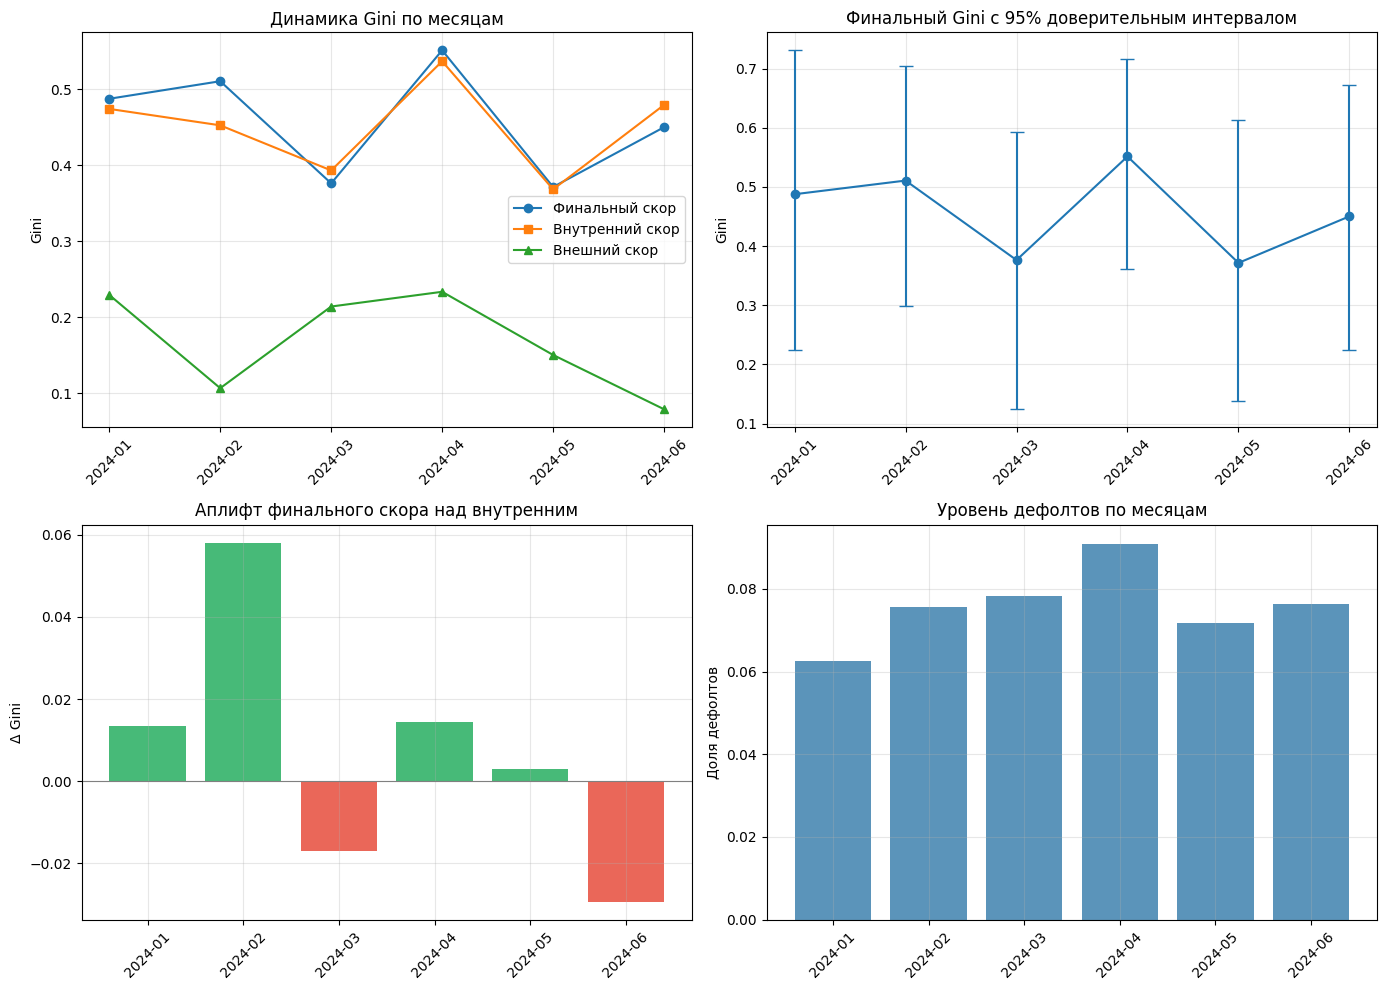

Сводка по метрикам:
  Средний Gini финального скора:  0.458
  Средний Gini внутреннего скора: 0.451
  Средний Gini внешнего скора:    0.169
  Средний аплифт:                 0.007
  Медианный аплифт:               0.008


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
months = metrics_df["month"].astype(str)

# (1) Динамика Gini по трём скорам
ax = axes[0, 0]
ax.plot(months, metrics_df["gini_final"], marker="o", label="Финальный скор")
ax.plot(months, metrics_df["gini_internal"], marker="s", label="Внутренний скор")
ax.plot(months, metrics_df["gini_external"], marker="^", label="Внешний скор")
ax.set_title("Динамика Gini по месяцам")
ax.set_ylabel("Gini")
ax.tick_params(axis="x", rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

# (2) Финальный Gini с 95% бутстрэп-доверительным интервалом
ax = axes[0, 1]
ax.errorbar(
    months, metrics_df["gini_final"],
    yerr=[metrics_df["gini_final"] - metrics_df["ci_lower"],
          metrics_df["ci_upper"] - metrics_df["gini_final"]],
    marker="o", capsize=5,
)
ax.set_title("Финальный Gini с 95% доверительным интервалом")
ax.set_ylabel("Gini")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3)

# (3) Аплифт финального скора над внутренним
ax = axes[1, 0]
uplift_colors = ["#27AE60" if v > 0 else "#E74C3C" for v in metrics_df["uplift"]]
ax.bar(months, metrics_df["uplift"], color=uplift_colors, alpha=0.85)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title("Аплифт финального скора над внутренним")
ax.set_ylabel("Δ Gini")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3)

# (4) Уровень дефолтов по месяцам
ax = axes[1, 1]
ax.bar(months, metrics_df["default_rate"], color="#2471A3", alpha=0.75)
ax.set_title("Уровень дефолтов по месяцам")
ax.set_ylabel("Доля дефолтов")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("gini_monitoring.png", dpi=150, bbox_inches="tight")
plt.show()

print("Сводка по метрикам:")
print(f"  Средний Gini финального скора:  {metrics_df['gini_final'].mean():.3f}")
print(f"  Средний Gini внутреннего скора: {metrics_df['gini_internal'].mean():.3f}")
print(f"  Средний Gini внешнего скора:    {metrics_df['gini_external'].mean():.3f}")
print(f"  Средний аплифт:                 {metrics_df['uplift'].mean():.3f}")
print(f"  Медианный аплифт:               {metrics_df['uplift'].median():.3f}")

## 5. Итоговые выводы

Агрегируем результаты в простой «светофор» качества модели и оцениваем её стабильность во времени.

In [6]:
avg_gini_final = metrics_df["gini_final"].mean()

if avg_gini_final < GINI_RED_THRESHOLD:
    signal = "КРАСНЫЙ"
elif avg_gini_final < GINI_YELLOW_THRESHOLD:
    signal = "ЖЁЛТЫЙ"
else:
    signal = "ЗЕЛЁНЫЙ"

positive_uplift_months = int((metrics_df["uplift"] > 0).sum())
total_months = len(metrics_df)
gini_std = metrics_df["gini_final"].std()

print("=" * 55)
print("ИТОГОВЫЕ ВЫВОДЫ")
print("=" * 55)
print(f"Среднее качество финальной модели (Gini): {avg_gini_final:.3f}")
print(f"Сигнал светофора: {signal}")
print()
print("Эффективность внешнего скора:")
print(f"  Месяцев с положительным аплифтом: "
      f"{positive_uplift_months} из {total_months} "
      f"({positive_uplift_months / total_months:.0%})")
print()
print("Стабильность модели:")
print(f"  Стандартное отклонение Gini по месяцам: {gini_std:.3f}")
print("=" * 55)

ИТОГОВЫЕ ВЫВОДЫ
Среднее качество финальной модели (Gini): 0.458
Сигнал светофора: ЖЁЛТЫЙ

Эффективность внешнего скора:
  Месяцев с положительным аплифтом: 4 из 6 (67%)

Стабильность модели:
  Стандартное отклонение Gini по месяцам: 0.073
